In [ ]:
!pip install deepxde torch scipy matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.1 MB/s eta 0:00:00


In [ ]:
import os
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


     year  t_normalized  hares_thousands  lynx_thousands  hares_scaled  \
0  1900.0          0.00             30.0             4.0      0.387597   
1  1901.0          0.05             47.2             6.1      0.609819   
2  1902.0          0.10             70.2             9.8      0.906977   
3  1903.0          0.15             77.4            35.2      1.000000   
4  1904.0          0.20             36.3            59.4      0.468992   

   lynx_scaled  
0     0.051680  
1     0.078811  
2     0.126615  
3     0.454780  
4     0.767442  


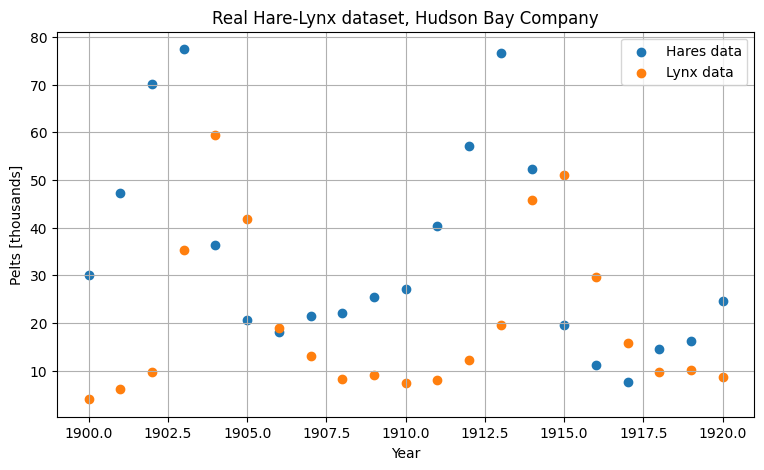

/tmp/ipykernel_1945/1671217479.py:117: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H0 = float(h_obs[0])
/tmp/ipykernel_1945/1671217479.py:118: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  L0 = float(l_obs[0])


Compiling model...
'compile' took 5.710048 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [1.91e-01, 2.86e-02, 3.81e+00, 3.79e+00]    [1.91e-01, 2.86e-02, 3.81e+00, 3.79e+00]    []  
1000      [6.09e-01, 5.46e-01, 2.15e+00, 1.37e+00]    [6.07e-01, 5.43e-01, 2.15e+00, 1.37e+00]    []  
2000      [6.10e-01, 5.51e-01, 2.12e+00, 1.35e+00]    [6.06e-01, 5.49e-01, 2.12e+00, 1.35e+00]    []  
3000      [6.14e-01, 5.62e-01, 2.07e+00, 1.31e+00]    [6.11e-01, 5.60e-01, 2.07e+00, 1.31e+00]    []  
4000      [6.22e-01, 5.75e-01, 2.02e+00, 1.28e+00]    [6.19e-01, 5.73e-01, 2.02e+00, 1.28e+00]    []  
5000      [6.23e-01, 5.92e-01, 1.96e+00, 1.24e+00]    [6.20e-01, 5.90e-01, 1.96e+00, 1.24e+00]    []  
6000      [6.28e-01, 6.09e-01, 1.90e+00, 1.19e+00]    [6.26e-01, 6.07e-01, 1.90e+00, 1.19e+00]    []  
7000      [6.57e-01, 6.25e-01, 1.85e+00, 1.14e+00]    [6.55e-01, 6.24e-01, 1.85e+00, 1.14e+00]    []  
8

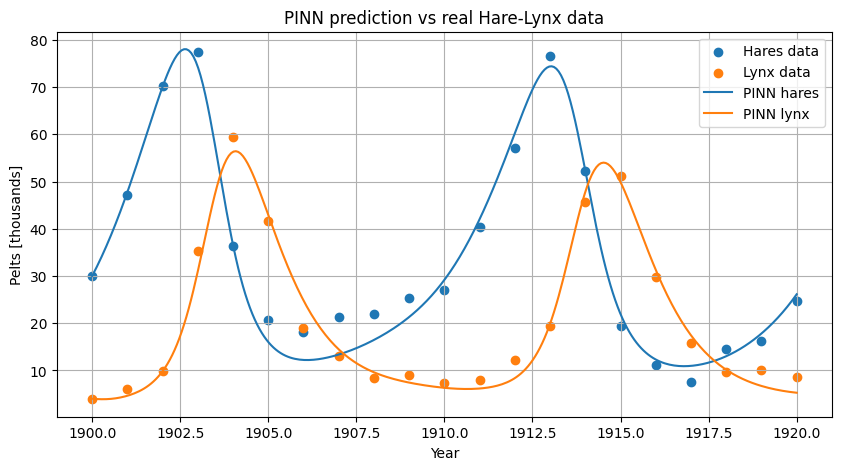

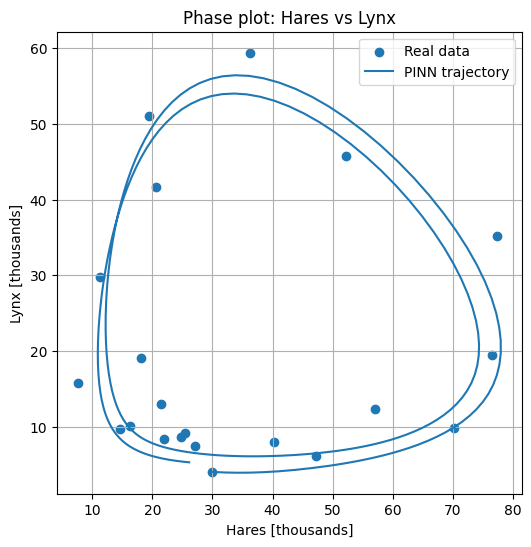

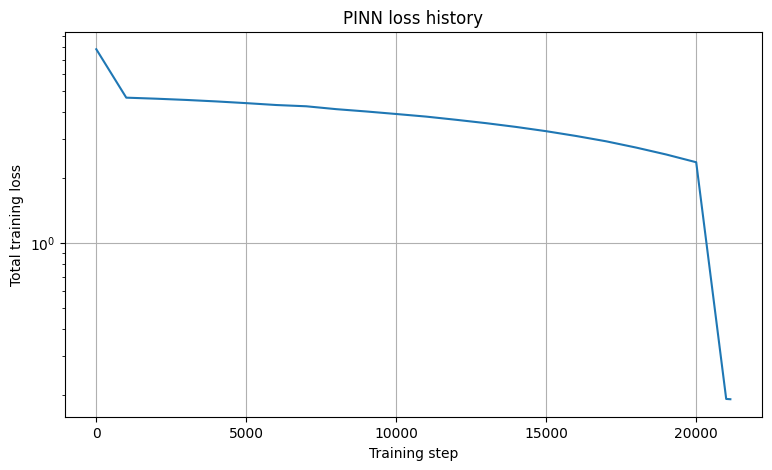

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


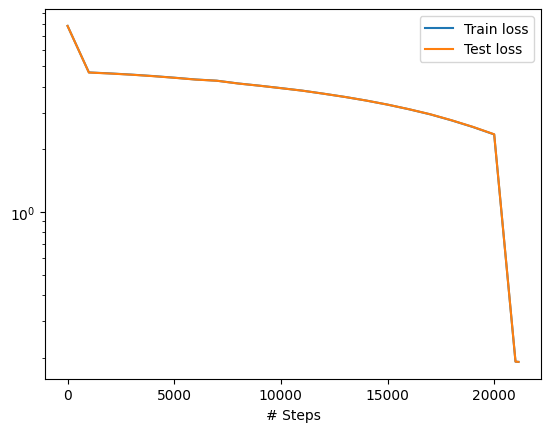

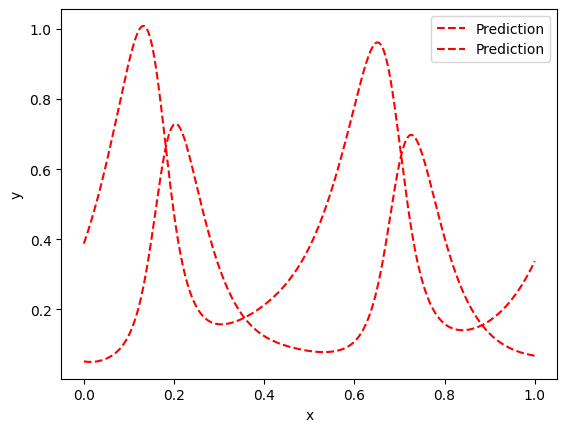


Learned parameters:
  parameter  learned_value                      meaning
0         A      11.062288          natural hare growth
1         B      41.996193     hare loss caused by lynx
2         C      17.754725           natural lynx decay
3         D      40.727962  lynx growth caused by hares

Generated files:
hare_lynx_real_dataset.csv
01_real_data.png
02_learned_parameters_history.dat
03_pinn_vs_real_data.png
04_phase_plot.png
05_loss_history.png
06_learned_parameters.csv


In [ ]:

# 1. REALNY DATASET HARE-LYNX 1900-1920
# Dane w tysiącach sztuk

years = np.array([
    1900, 1901, 1902, 1903, 1904, 1905, 1906,
    1907, 1908, 1909, 1910, 1911, 1912, 1913,
    1914, 1915, 1916, 1917, 1918, 1919, 1920
], dtype=float).reshape(-1, 1)

hares = np.array([
    30.0, 47.2, 70.2, 77.4, 36.3, 20.6, 18.1,
    21.4, 22.0, 25.4, 27.1, 40.3, 57.0, 76.6,
    52.3, 19.5, 11.2, 7.6, 14.6, 16.2, 24.7
], dtype=float).reshape(-1, 1)

lynx = np.array([
    4.0, 6.1, 9.8, 35.2, 59.4, 41.7, 19.0,
    13.0, 8.3, 9.1, 7.4, 8.0, 12.3, 19.5,
    45.7, 51.1, 29.7, 15.8, 9.7, 10.1, 8.6
], dtype=float).reshape(-1, 1)


# 2. NORMALIZACJA


t_obs = (years - years.min()) / (years.max() - years.min())

population_scale = max(hares.max(), lynx.max())

h_obs = hares / population_scale
l_obs = lynx / population_scale



df = pd.DataFrame({
    "year": years.flatten(),
    "t_normalized": t_obs.flatten(),
    "hares_thousands": hares.flatten(),
    "lynx_thousands": lynx.flatten(),
    "hares_scaled": h_obs.flatten(),
    "lynx_scaled": l_obs.flatten(),
})

df.to_csv("hare_lynx_real_dataset.csv", index=False)

print(df.head())

# 3. WYKRES REALNYCH DANYCH

plt.figure(figsize=(9, 5))
plt.scatter(years, hares, label="Hares data")
plt.scatter(years, lynx, label="Lynx data")
plt.xlabel("Year")
plt.ylabel("Pelts [thousands]")
plt.title("Real Hare-Lynx dataset, Hudson Bay Company")
plt.legend()
plt.grid(True)
plt.savefig("01_real_data.png", dpi=300)
plt.show()


# 4. PARAMETRY, KTÓRYCH MODEL MA SIĘ NAUCZYĆ


# To są nieznane parametry modelu Lotka-Volterra.
# Startujemy od zgadywanych wartości.
# Podczas treningu DeepXDE będzie je optymalizować razem z wagami sieci.

A = dde.Variable(1.0)
B = dde.Variable(1.0)
C = dde.Variable(1.0)
D = dde.Variable(1.0)

# 5. DEFINICJA RÓWNANIA LOTKA-VOLTERRA


def lotka_volterra_ode(t, y):
    """
    t - czas znormalizowany od 0 do 1
    y - wyjście sieci neuronowej:
        y[:, 0:1] = H(t), czyli hares
        y[:, 1:2] = L(t), czyli lynx
    """

    H = y[:, 0:1]
    L = y[:, 1:2]

    # DeepXDE liczy pochodne automatycznie.
    dH_dt = dde.grad.jacobian(y, t, i=0)
    dL_dt = dde.grad.jacobian(y, t, i=1)

    # Residual równania.
    # Jeśli sieć idealnie spełnia równanie, te wartości powinny być bliskie 0.

    eq_H = dH_dt - (A * H - B * H * L)
    eq_L = dL_dt - (-C * L + D * H * L)

    return [eq_H, eq_L]


# 6. DZIEDZINA CZASU


geom = dde.geometry.TimeDomain(0.0, 1.0)


# 7. DODANIE DANYCH POMIAROWYCH


observe_H = dde.icbc.PointSetBC(t_obs, h_obs, component=0)
observe_L = dde.icbc.PointSetBC(t_obs, l_obs, component=1)


# 8. HARD CONSTRAINT DLA WARUNKU POCZĄTKOWEGO


H0 = float(h_obs[0])
L0 = float(l_obs[0])

def output_transform(t, y):
    """
    Chcemy, żeby model zawsze spełniał:
    H(0) = H0
    L(0) = L0

    Ponieważ tanh(0) = 0, to dla t=0:
    H_out(0) = H0
    L_out(0) = L0
    """

    y1 = y[:, 0:1]
    y2 = y[:, 1:2]

    H_out = H0 + torch.tanh(t) * y1
    L_out = L0 + torch.tanh(t) * y2

    return torch.cat([H_out, L_out], dim=1)


# 9. OBIEKT DANYCH DeepXDE


data = dde.data.PDE(
    geometry=geom,
    pde=lotka_volterra_ode,
    bcs=[observe_H, observe_L],
    num_domain=1000,
    num_boundary=2,
    anchors=t_obs,
    num_test=1000,
)

# 10. SIEĆ NEURONOWA

layer_size = [1] + [64] * 4 + [2]
activation = "tanh"
initializer = "Glorot normal"

net = dde.nn.FNN(layer_size, activation, initializer)

net.apply_output_transform(output_transform)


# 11. MODEL I TRENING ADAM


model = dde.Model(data, net)

model.compile(
    optimizer="adam",
    lr=0.001,
    loss_weights=[1, 1, 50, 50],
    external_trainable_variables=[A, B, C, D],
)

variable_callback = dde.callbacks.VariableValue(
    [A, B, C, D],
    period=1000,
    filename="02_learned_parameters_history.dat",
)

losshistory, train_state = model.train(
    iterations=20000,
    callbacks=[variable_callback],
)


# 12. DOPRACOWANIE L-BFGS


model.compile(
    optimizer="L-BFGS",
    loss_weights=[1, 1, 50, 50],
    external_trainable_variables=[A, B, C, D],
)

losshistory, train_state = model.train(
    callbacks=[variable_callback]
)


# 13. PREDYKCJA MODELU


t_pred = np.linspace(0, 1, 300).reshape(-1, 1)
y_pred = model.predict(t_pred)

H_pred_scaled = y_pred[:, 0:1]
L_pred_scaled = y_pred[:, 1:2]

# Wracamy do skali tysięcy sztuk.
H_pred = H_pred_scaled * population_scale
L_pred = L_pred_scaled * population_scale

years_pred = years.min() + t_pred * (years.max() - years.min())


# 14. WYKRES PINN VS REALNE DANE


plt.figure(figsize=(10, 5))

plt.scatter(years, hares, label="Hares data")
plt.scatter(years, lynx, label="Lynx data")

plt.plot(years_pred, H_pred, label="PINN hares")
plt.plot(years_pred, L_pred, label="PINN lynx")

plt.xlabel("Year")
plt.ylabel("Pelts [thousands]")
plt.title("PINN prediction vs real Hare-Lynx data")
plt.legend()
plt.grid(True)
plt.savefig("03_pinn_vs_real_data.png", dpi=300)
plt.show()


# 15. WYKRES FAZOWY: HARES VS LYNX


plt.figure(figsize=(6, 6))

plt.scatter(hares, lynx, label="Real data")
plt.plot(H_pred, L_pred, label="PINN trajectory")

plt.xlabel("Hares [thousands]")
plt.ylabel("Lynx [thousands]")
plt.title("Phase plot: Hares vs Lynx")
plt.legend()
plt.grid(True)
plt.savefig("04_phase_plot.png", dpi=300)
plt.show()

# 16. WYKRES LOSS HISTORY

loss_train = np.sum(np.array(losshistory.loss_train), axis=1)

plt.figure(figsize=(9, 5))
plt.semilogy(losshistory.steps, loss_train)
plt.xlabel("Training step")
plt.ylabel("Total training loss")
plt.title("PINN loss history")
plt.grid(True)
plt.savefig("05_loss_history.png", dpi=300)
plt.show()

dde.saveplot(losshistory, train_state, issave=True, isplot=True)


# 17. ZAPIS PARAMETRÓW


def get_value(v):
    try:
        return float(v.detach().cpu().numpy())
    except Exception:
        return float(v.value())


learned_params = pd.DataFrame({
    "parameter": ["A", "B", "C", "D"],
    "learned_value": [
        get_value(A),
        get_value(B),
        get_value(C),
        get_value(D),
    ],
    "meaning": [
        "natural hare growth",
        "hare loss caused by lynx",
        "natural lynx decay",
        "lynx growth caused by hares",
    ],
})

learned_params.to_csv("06_learned_parameters.csv", index=False)

print("\nLearned parameters:")
print(learned_params)

print("\nGenerated files:")
print("hare_lynx_real_dataset.csv")
print("01_real_data.png")
print("02_learned_parameters_history.dat")
print("03_pinn_vs_real_data.png")
print("04_phase_plot.png")
print("05_loss_history.png")
print("06_learned_parameters.csv")